# Большой тестовый notebook для Jupyter-движка

Этот notebook проверяет типичный интерактивный сценарий работы Jupyter:

- выполнение обычных Python-ячеек и IPython-команд;
- отображение Markdown, HTML и табличных данных;
- вычисления с **NumPy**;
- очистку, агрегацию и преобразование данных с **pandas**;
- построение нескольких типов графиков с **Matplotlib**;
- работу с временными файлами, shell-командами, исключениями и `asyncio`;
- последовательное использование состояния, созданного предыдущими ячейками.

Данные полностью синтетические, генератор случайных чисел зафиксирован. Notebook не требует сети и не изменяет файлы проекта.

## 1. Проверка окружения

Сначала загрузим зависимости и выведем информацию о Python и операционной системе. Если эта секция выполняется, ядро умеет запускать код и сохранять состояние между ячейками.

In [1]:
from __future__ import annotations

import asyncio
import os
import platform
import shutil
import sys
import tempfile
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display

print(f"Python:     {sys.version.split()[0]}")
print(f"Platform:   {platform.platform()}")
print(f"Executable: {sys.executable}")

ModuleNotFoundError: No module named 'matplotlib'

In [2]:
!python --version
!pwd
!git --version

Python 3.12.7


/Users/germankochnev/Desktop/projects/alteracts/alteracts-scene-orchestrator/notebooks


git version 2.50.1 (Apple Git-155)


In [3]:
%matplotlib inline

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
plt.style.use("seaborn-v0_8-whitegrid")

versions = pd.DataFrame(
    {
        "library": ["numpy", "pandas", "matplotlib"],
        "version": [np.__version__, pd.__version__, matplotlib.__version__],
    }
)
versions

,library,version
0,numpy,2.3.4
1,pandas,2.3.3
2,matplotlib,3.10.6


## 2. Генерация набора данных

Смоделируем телеметрию движка оркестрации сцен. Каждая строка представляет обработанный beat. В данных есть время, тип сцены, канал, задержка, длительность, энергия аудио, confidence, число токенов и флаг прерывания.

Намеренно добавим несколько пропусков и выбросов — они понадобятся для проверки операций очистки.

In [4]:
SEED = 20260831
ROW_COUNT = 2_400
rng = np.random.default_rng(SEED)

timestamps = pd.date_range("2026-08-01", periods=ROW_COUNT, freq="30s", tz="UTC")
scene_types = np.array(["dialogue", "action", "reflection", "transition"])
channels = np.array(["voice", "music", "effects"])
speakers = np.array(["narrator", "actor_a", "actor_b", "system"])

print(f"Seed: {SEED}")
print(f"Rows to generate: {ROW_COUNT:,}")

Seed: 20260831
Rows to generate: 2,400


In [5]:
scene = rng.choice(scene_types, ROW_COUNT, p=[0.48, 0.22, 0.20, 0.10])
channel = rng.choice(channels, ROW_COUNT, p=[0.62, 0.20, 0.18])
speaker = rng.choice(speakers, ROW_COUNT, p=[0.22, 0.31, 0.31, 0.16])

scene_latency_effect = pd.Series(scene).map(
    {"dialogue": 35, "action": 90, "reflection": 55, "transition": 15}
).to_numpy()
channel_energy_effect = pd.Series(channel).map(
    {"voice": 0.05, "music": 0.22, "effects": 0.32}
).to_numpy()

raw = pd.DataFrame(
    {
        "timestamp": timestamps,
        "beat_id": [f"beat-{number:05d}" for number in range(1, ROW_COUNT + 1)],
        "scene": scene,
        "channel": channel,
        "speaker": speaker,
        "duration_ms": rng.gamma(shape=3.5, scale=260, size=ROW_COUNT),
        "latency_ms": rng.normal(180, 38, ROW_COUNT) + scene_latency_effect,
        "energy": np.clip(rng.beta(2.4, 4.0, ROW_COUNT) + channel_energy_effect, 0, 1),
        "confidence": np.clip(rng.normal(0.88, 0.08, ROW_COUNT), 0, 1),
        "tokens": rng.poisson(24, ROW_COUNT),
        "interrupted": rng.random(ROW_COUNT) < 0.075,
    }
)

raw.head(8)

,timestamp,beat_id,scene,channel,speaker,duration_ms,latency_ms,energy,confidence,tokens,interrupted
0,2026-08-01 00:00:00+00:00,beat-00001,dialogue,voice,narrator,753.616220,214.525916,0.428507,0.699329,34,True
1,2026-08-01 00:00:30+00:00,beat-00002,action,music,narrator,942.738974,236.200850,0.330149,0.928732,24,False
2,2026-08-01 00:01:00+00:00,beat-00003,transition,music,actor_a,1492.972343,187.784792,0.828344,0.880919,22,False
3,2026-08-01 00:01:30+00:00,beat-00004,reflection,music,actor_a,1087.412351,224.385482,0.448074,0.790467,24,True
4,2026-08-01 00:02:00+00:00,beat-00005,action,voice,narrator,303.101661,329.225854,0.356310,0.939989,18,False
5,2026-08-01 00:02:30+00:00,beat-00006,transition,voice,actor_b,561.426310,175.336510,0.163156,0.827170,23,False
6,2026-08-01 00:03:00+00:00,beat-00007,reflection,effects,actor_b,1479.102843,280.194165,0.837864,0.876543,34,False
7,2026-08-01 00:03:30+00:00,beat-00008,action,music,actor_a,260.392473,197.436893,0.360991,0.878581,18,False


In [6]:
# Вносим контролируемые проблемы качества данных.
missing_latency_rows = rng.choice(raw.index, size=24, replace=False)
missing_confidence_rows = rng.choice(raw.index, size=18, replace=False)
outlier_rows = rng.choice(raw.index, size=8, replace=False)

raw.loc[missing_latency_rows, "latency_ms"] = np.nan
raw.loc[missing_confidence_rows, "confidence"] = np.nan
raw.loc[outlier_rows, "latency_ms"] *= 4

quality_issues = pd.Series(
    {
        "missing latency": int(raw["latency_ms"].isna().sum()),
        "missing confidence": int(raw["confidence"].isna().sum()),
        "latency over 600 ms": int(raw["latency_ms"].gt(600).sum()),
    },
    name="rows",
)
quality_issues.to_frame()

,rows
missing latency,24
missing confidence,18
latency over 600 ms,8


### Схема данных

| Поле | Тип | Смысл |
|---|---:|---|
| `timestamp` | datetime | время обработки beat |
| `beat_id` | string | уникальный идентификатор |
| `scene` | category | тип сцены |
| `channel` | category | аудиоканал |
| `duration_ms` | float | длительность beat |
| `latency_ms` | float | задержка обработки |
| `energy` | float | нормализованная энергия сигнала |
| `confidence` | float | уверенность распознавания |
| `tokens` | int | число обработанных токенов |
| `interrupted` | bool | был ли beat прерван |

In [7]:
schema = pd.DataFrame(
    {
        "dtype": raw.dtypes.astype(str),
        "non_null": raw.notna().sum(),
        "missing": raw.isna().sum(),
        "unique": raw.nunique(),
    }
)
schema

,dtype,non_null,missing,unique
timestamp,"datetime64[ns, UTC]",2400,0,2400
beat_id,object,2400,0,2400
scene,object,2400,0,4
channel,object,2400,0,3
speaker,object,2400,0,4
duration_ms,float64,2400,0,2400
latency_ms,float64,2376,24,2376
energy,float64,2400,0,2367
confidence,float64,2382,18,2225
tokens,int64,2400,0,35


In [8]:
memory_before = raw.memory_usage(deep=True).sum()

for column in ["scene", "channel", "speaker"]:
    raw[column] = raw[column].astype("category")

memory_after = raw.memory_usage(deep=True).sum()
pd.Series(
    {
        "before_mb": memory_before / 1024**2,
        "after_mb": memory_after / 1024**2,
        "saved_percent": 100 * (1 - memory_after / memory_before),
    }
).round(3).to_frame("value")

,value
before_mb,0.631
after_mb,0.255
saved_percent,59.542


## 3. Очистка и feature engineering

Заполним пропуски медианой внутри соответствующего типа сцены, ограничим экстремальную задержку по квантилям и вычислим несколько производных признаков.

In [9]:
df = raw.copy()

df["latency_ms"] = df["latency_ms"].fillna(
    df.groupby("scene", observed=True)["latency_ms"].transform("median")
)
df["confidence"] = df["confidence"].fillna(df["confidence"].median())

latency_lower, latency_upper = df["latency_ms"].quantile([0.01, 0.99])
df["latency_ms_clipped"] = df["latency_ms"].clip(latency_lower, latency_upper)
df["duration_s"] = df["duration_ms"] / 1_000
df["tokens_per_second"] = df["tokens"] / df["duration_s"].clip(lower=0.05)
df["minute"] = df["timestamp"].dt.floor("min")
df["hour"] = df["timestamp"].dt.hour
df["quality_score"] = (
    0.55 * df["confidence"]
    + 0.25 * (1 - df["latency_ms_clipped"] / df["latency_ms_clipped"].max())
    + 0.20 * (1 - df["interrupted"].astype(float))
)

df.sample(6, random_state=SEED)

,timestamp,beat_id,scene,channel,speaker,duration_ms,latency_ms,energy,confidence,tokens,interrupted,latency_ms_clipped,duration_s,tokens_per_second,minute,hour,quality_score
1705,2026-08-01 14:12:30+00:00,beat-01706,reflection,voice,actor_a,669.294362,199.724480,0.360771,0.828671,24,False,199.724480,0.669294,35.858662,2026-08-01 14:12:00+00:00,14,0.759219
519,2026-08-01 04:19:30+00:00,beat-00520,transition,voice,narrator,341.435805,262.497432,0.205887,0.767813,18,False,262.497432,0.341436,52.718548,2026-08-01 04:19:00+00:00,4,0.679687
350,2026-08-01 02:55:00+00:00,beat-00351,reflection,voice,actor_a,370.511474,263.841058,0.395183,0.874559,29,False,263.841058,0.370511,78.270181,2026-08-01 02:55:00+00:00,2,0.737411
1694,2026-08-01 14:07:00+00:00,beat-01695,dialogue,voice,narrator,805.477346,206.344719,0.544279,0.853240,22,False,206.344719,0.805477,27.312997,2026-08-01 14:07:00+00:00,14,0.767874
1817,2026-08-01 15:08:30+00:00,beat-01818,action,music,actor_b,855.857007,292.356073,0.741395,0.875768,18,False,292.356073,0.855857,21.031551,2026-08-01 15:08:00+00:00,15,0.717153
454,2026-08-01 03:47:00+00:00,beat-00455,reflection,effects,actor_a,1352.116066,243.853529,0.675895,0.885087,21,False,243.853529,1.352116,15.531211,2026-08-01 03:47:00+00:00,3,0.757868


In [10]:
assert len(df) == ROW_COUNT
assert df["beat_id"].is_unique
assert not df[["latency_ms", "confidence"]].isna().any().any()
assert df["energy"].between(0, 1).all()
assert df["confidence"].between(0, 1).all()
assert df["quality_score"].between(0, 1).all()

print("✓ Все проверки целостности данных пройдены")

✓ Все проверки целостности данных пройдены


In [11]:
numeric_summary = df[
    ["duration_ms", "latency_ms", "energy", "confidence", "tokens", "quality_score"]
].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

numeric_summary.round(3)

,count,mean,std,min,5%,25%,50%,75%,95%,max
duration_ms,2400.0,905.159,484.763,47.680,278.451,553.626,815.977,1159.585,1851.384,3304.977
latency_ms,2400.0,230.829,60.923,82.610,155.689,196.874,227.588,259.542,305.241,1045.514
energy,2400.0,0.500,0.211,0.063,0.182,0.336,0.483,0.649,0.871,1.000
confidence,2400.0,0.878,0.076,0.590,0.749,0.828,0.879,0.935,1.000,1.000
tokens,2400.0,23.945,4.812,9.000,16.000,21.000,24.000,27.000,32.000,48.000
quality_score,2400.0,0.751,0.074,0.417,0.592,0.720,0.761,0.799,0.845,0.907


## 4. Группировки и сводные таблицы

Следующие ячейки проверяют `groupby`, именованные агрегации, сортировку, `pivot_table`, форматирование DataFrame и работу с временными индексами.

In [12]:
scene_summary = (
    df.groupby("scene", observed=True)
    .agg(
        beats=("beat_id", "count"),
        mean_latency_ms=("latency_ms", "mean"),
        p95_latency_ms=("latency_ms", lambda values: values.quantile(0.95)),
        mean_duration_ms=("duration_ms", "mean"),
        mean_confidence=("confidence", "mean"),
        interruption_rate=("interrupted", "mean"),
        total_tokens=("tokens", "sum"),
    )
    .sort_values("mean_latency_ms", ascending=False)
)

scene_summary.round(3)

,beats,mean_latency_ms,p95_latency_ms,mean_duration_ms,mean_confidence,interruption_rate,total_tokens
scene,,,,,,,
action,537,271.753,329.920,921.277,0.874,0.074,12955
reflection,472,235.799,295.325,905.245,0.874,0.064,11396
dialogue,1142,217.453,278.485,904.283,0.881,0.069,27197
transition,249,194.499,254.752,874.253,0.879,0.064,5919


In [13]:
channel_scene_pivot = pd.pivot_table(
    df,
    values="latency_ms",
    index="scene",
    columns="channel",
    aggfunc="mean",
    observed=True,
)

channel_scene_pivot.round(2)

channel,effects,music,voice
scene,,,
action,268.95,267.55,273.84
dialogue,230.49,215.58,214.75
reflection,236.85,231.94,236.75
transition,211.95,196.97,189.29


In [14]:
minute_metrics = (
    df.set_index("timestamp")
    .resample("5min")
    .agg(
        beats=("beat_id", "count"),
        latency_ms=("latency_ms_clipped", "mean"),
        confidence=("confidence", "mean"),
        interruption_rate=("interrupted", "mean"),
    )
)

minute_metrics["latency_rolling_20m"] = minute_metrics["latency_ms"].rolling(4, min_periods=1).mean()
minute_metrics.head(10).round(3)

,beats,latency_ms,confidence,interruption_rate,latency_rolling_20m
timestamp,,,,,
2026-08-01 00:00:00+00:00,10,229.970,0.882,0.3,229.970
2026-08-01 00:05:00+00:00,10,213.911,0.869,0.0,221.940
2026-08-01 00:10:00+00:00,10,237.309,0.866,0.1,227.063
2026-08-01 00:15:00+00:00,10,234.170,0.835,0.0,228.840
2026-08-01 00:20:00+00:00,10,223.333,0.909,0.0,227.180
2026-08-01 00:25:00+00:00,10,241.338,0.855,0.1,234.037
2026-08-01 00:30:00+00:00,10,232.663,0.883,0.1,232.876
2026-08-01 00:35:00+00:00,10,220.167,0.882,0.1,229.375
2026-08-01 00:40:00+00:00,10,228.813,0.858,0.0,230.745


## 5. Визуализация Matplotlib

Будут построены временной ряд, гистограмма, scatter plot, столбчатая диаграмма, boxplot и heatmap. Это также проверяет inline-рендеринг PNG/SVG-вывода Jupyter.

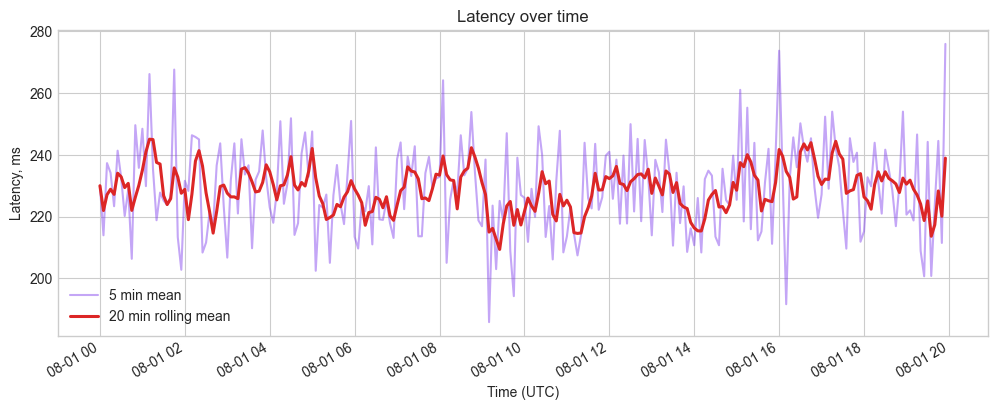

In [15]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(minute_metrics.index, minute_metrics["latency_ms"], color="#7c3aed", alpha=0.45, label="5 min mean")
ax.plot(
    minute_metrics.index,
    minute_metrics["latency_rolling_20m"],
    color="#dc2626",
    linewidth=2.2,
    label="20 min rolling mean",
)
ax.set(title="Latency over time", xlabel="Time (UTC)", ylabel="Latency, ms")
ax.legend()
fig.autofmt_xdate()
plt.show()

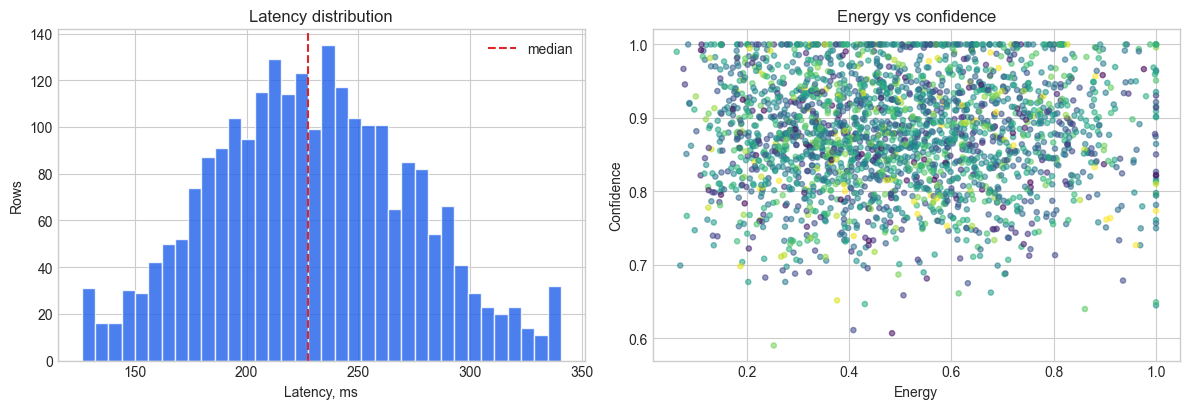

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].hist(df["latency_ms_clipped"], bins=36, color="#2563eb", alpha=0.82, edgecolor="white")
axes[0].axvline(df["latency_ms_clipped"].median(), color="#dc2626", linestyle="--", label="median")
axes[0].set(title="Latency distribution", xlabel="Latency, ms", ylabel="Rows")
axes[0].legend()

axes[1].scatter(
    df["energy"],
    df["confidence"],
    c=df["latency_ms_clipped"],
    cmap="viridis",
    s=14,
    alpha=0.55,
)
axes[1].set(title="Energy vs confidence", xlabel="Energy", ylabel="Confidence")

fig.tight_layout()
plt.show()

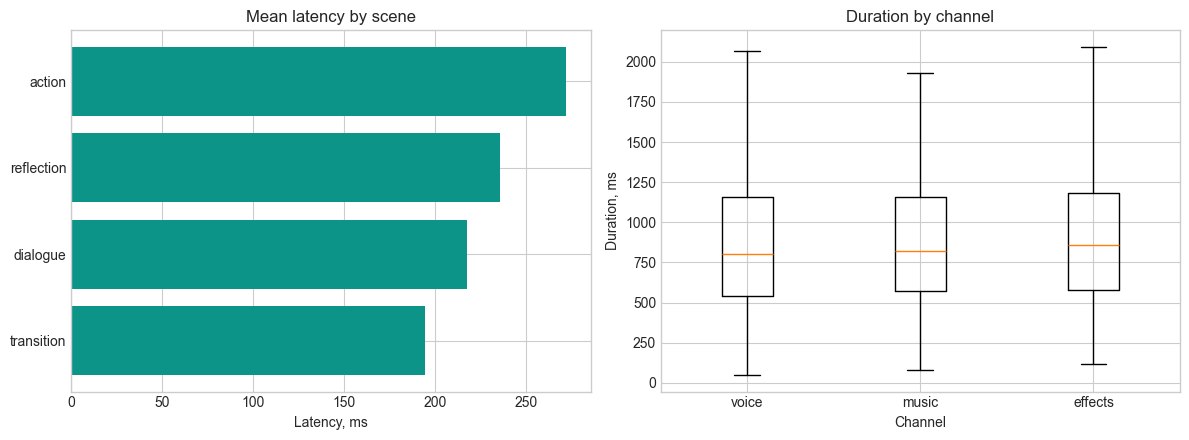

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ordered = scene_summary.sort_values("mean_latency_ms")
axes[0].barh(ordered.index.astype(str), ordered["mean_latency_ms"], color="#0d9488")
axes[0].set(title="Mean latency by scene", xlabel="Latency, ms")

box_data = [
    df.loc[df["channel"] == channel_name, "duration_ms"].to_numpy()
    for channel_name in channels
]
axes[1].boxplot(box_data, tick_labels=channels, showfliers=False)
axes[1].set(title="Duration by channel", xlabel="Channel", ylabel="Duration, ms")

fig.tight_layout()
plt.show()

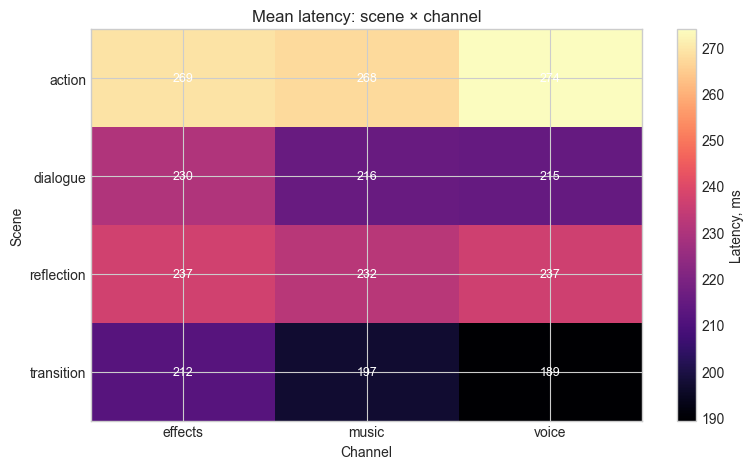

In [18]:
heatmap_values = channel_scene_pivot.to_numpy()

fig, ax = plt.subplots(figsize=(8, 4.8))
image = ax.imshow(heatmap_values, cmap="magma", aspect="auto")
ax.set_xticks(range(len(channel_scene_pivot.columns)), channel_scene_pivot.columns.astype(str))
ax.set_yticks(range(len(channel_scene_pivot.index)), channel_scene_pivot.index.astype(str))
ax.set(title="Mean latency: scene × channel", xlabel="Channel", ylabel="Scene")

for row_index in range(heatmap_values.shape[0]):
    for column_index in range(heatmap_values.shape[1]):
        ax.text(
            column_index,
            row_index,
            f"{heatmap_values[row_index, column_index]:.0f}",
            ha="center",
            va="center",
            color="white",
            fontsize=9,
        )

fig.colorbar(image, ax=ax, label="Latency, ms")
fig.tight_layout()
plt.show()

## 6. Численные вычисления NumPy

Эта часть нагружает векторные операции, broadcasting, линейную алгебру, собственные значения и симуляцию Monte Carlo.

In [19]:
feature_columns = ["duration_ms", "latency_ms_clipped", "energy", "confidence", "tokens"]
feature_matrix = df[feature_columns].to_numpy(dtype=np.float64)

means = feature_matrix.mean(axis=0)
stds = feature_matrix.std(axis=0)
standardized = (feature_matrix - means) / stds
correlation = np.corrcoef(standardized, rowvar=False)

correlation_frame = pd.DataFrame(correlation, index=feature_columns, columns=feature_columns)
correlation_frame.round(3)

,duration_ms,latency_ms_clipped,energy,confidence,tokens
duration_ms,1.000,0.008,-0.004,-0.017,-0.018
latency_ms_clipped,0.008,1.000,-0.006,0.022,0.002
energy,-0.004,-0.006,1.000,0.012,0.025
confidence,-0.017,0.022,0.012,1.000,0.012
tokens,-0.018,0.002,0.025,0.012,1.000


In [20]:
covariance = np.cov(standardized, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(covariance)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

explained_variance = eigenvalues / eigenvalues.sum()
principal_components = standardized @ eigenvectors[:, :2]

pd.DataFrame(
    {
        "component": np.arange(1, len(eigenvalues) + 1),
        "eigenvalue": eigenvalues,
        "explained_variance": explained_variance,
        "cumulative_variance": np.cumsum(explained_variance),
    }
).round(4)

,component,eigenvalue,explained_variance,cumulative_variance
0,1,1.0458,0.2091,0.2091
1,2,1.0169,0.2033,0.4124
2,3,0.9985,0.1996,0.6120
3,4,0.9778,0.1955,0.8075
4,5,0.9631,0.1925,1.0000


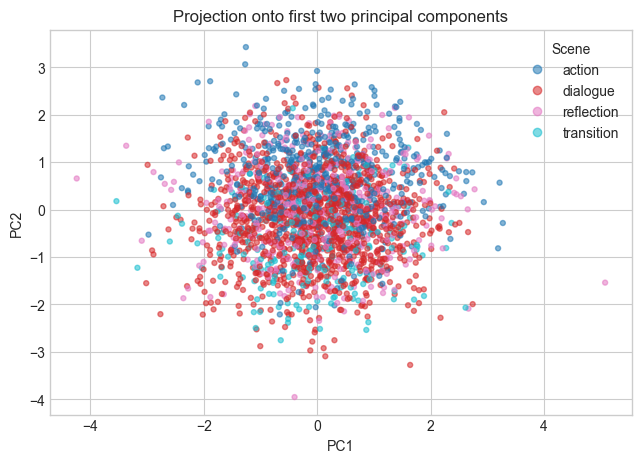

In [21]:
fig, ax = plt.subplots(figsize=(7.5, 5))
scene_codes = df["scene"].cat.codes.to_numpy()
scatter = ax.scatter(
    principal_components[:, 0],
    principal_components[:, 1],
    c=scene_codes,
    cmap="tab10",
    s=13,
    alpha=0.55,
)
ax.set(title="Projection onto first two principal components", xlabel="PC1", ylabel="PC2")
legend_handles, _ = scatter.legend_elements()
ax.legend(legend_handles, df["scene"].cat.categories, title="Scene", loc="best")
plt.show()

In [22]:
SIMULATIONS = 20_000
simulated_base_latency = rng.normal(
    loc=df["latency_ms_clipped"].mean(),
    scale=df["latency_ms_clipped"].std(),
    size=SIMULATIONS,
)
simulated_queue_delay = rng.exponential(scale=32, size=SIMULATIONS)
simulated_total_latency = np.maximum(simulated_base_latency + simulated_queue_delay, 0)

monte_carlo_result = pd.Series(
    {
        "simulations": SIMULATIONS,
        "mean_ms": simulated_total_latency.mean(),
        "p50_ms": np.quantile(simulated_total_latency, 0.50),
        "p95_ms": np.quantile(simulated_total_latency, 0.95),
        "p99_ms": np.quantile(simulated_total_latency, 0.99),
        "probability_over_350ms": np.mean(simulated_total_latency > 350),
    }
)
monte_carlo_result.to_frame("value").round(4)

,value
simulations,20000.0000
mean_ms,261.0772
p50_ms,257.8330
p95_ms,357.4442
p99_ms,410.4042
probability_over_350ms,0.0615


In [23]:
%%time

# Небольшой, но настоящий векторизованный workload.
benchmark_rng = np.random.default_rng(SEED + 1)
left = benchmark_rng.normal(size=(500, 180))
right = benchmark_rng.normal(size=(180, 120))
product = left @ right
checksum = float(np.square(product).mean())

print(f"Matrix shape: {product.shape}")
print(f"Checksum: {checksum:.6f}")

Matrix shape: (500, 120)
Checksum: 181.826594
CPU times: user 1.07 ms, sys: 422 μs, total: 1.49 ms
Wall time: 1.64 ms


## 7. Временные файлы и shell-команды

Notebook создаёт временный каталог вне репозитория, записывает туда CSV и PNG, читает метаданные shell-командами, а затем гарантированно удаляет каталог.

In [24]:
temporary_directory = Path(tempfile.mkdtemp(prefix="jupyter-engine-smoke-"))
csv_path = temporary_directory / "scene_summary.csv"
figure_path = temporary_directory / "latency_preview.png"

scene_summary.to_csv(csv_path)

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(minute_metrics.index[:20], minute_metrics["latency_ms"].iloc[:20], marker="o", color="#7c3aed")
ax.set(title="Exported latency preview", ylabel="Latency, ms")
fig.tight_layout()
fig.savefig(figure_path, dpi=120)
plt.close(fig)

print(temporary_directory)
print(f"CSV exists: {csv_path.exists()}")
print(f"PNG exists: {figure_path.exists()}")

/var/folders/6h/prv76kd151d6bp5g1g301l300000gn/T/jupyter-engine-smoke-o1o6ilz5
CSV exists: True
PNG exists: True


In [25]:
!ls -lh "$temporary_directory"
!python -c "from pathlib import Path; p=Path(r'$csv_path'); print('CSV lines:', sum(1 for _ in p.open()))"

total 80
-rw-r--r--@ 1 germankochnev  staff    36K Aug 31 13:30 latency_preview.png
-rw-r--r--@ 1 germankochnev  staff   554B Aug 31 13:30 scene_summary.csv


Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Users/germankochnev/.pyenv/versions/3.12.7/lib/python3.12/pathlib.py", line 1013, in open
    return io.open(self, mode, buffering, encoding, errors, newline)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
IsADirectoryError: [Errno 21] Is a directory: '.'


In [26]:
round_trip = pd.read_csv(csv_path, index_col="scene")
display(round_trip.round(3))

assert round_trip.shape == scene_summary.shape
assert figure_path.stat().st_size > 0
print("✓ CSV round trip and PNG export succeeded")

,beats,mean_latency_ms,p95_latency_ms,mean_duration_ms,mean_confidence,interruption_rate,total_tokens
scene,,,,,,,
action,537,271.753,329.920,921.277,0.874,0.074,12955
reflection,472,235.799,295.325,905.245,0.874,0.064,11396
dialogue,1142,217.453,278.485,904.283,0.881,0.069,27197
transition,249,194.499,254.752,874.253,0.879,0.064,5919


✓ CSV round trip and PNG export succeeded


In [27]:
shutil.rmtree(temporary_directory)
assert not temporary_directory.exists()
print("✓ Temporary files removed")

✓ Temporary files removed


## 8. Состояние ядра, ошибки и async

Последние проверки показывают, что переменные из ранних ячеек сохранились, ожидаемая ошибка может быть обработана, а event loop поддерживает top-level `await`.

In [28]:
try:
    _ = df["column_that_does_not_exist"]
except KeyError as error:
    handled_error = type(error).__name__
    print(f"✓ Expected error handled: {handled_error}")
else:
    raise AssertionError("The expected KeyError was not raised")

✓ Expected error handled: KeyError


In [29]:
async def calculate_async_metric(values: pd.Series) -> float:
    await asyncio.sleep(0.01)
    return float(values.mean())


async_mean_latency = await calculate_async_metric(df["latency_ms_clipped"])
print(f"Async mean latency: {async_mean_latency:.3f} ms")

Async mean latency: 228.936 ms


In [30]:
top_scenes = scene_summary.nsmallest(3, "mean_latency_ms").reset_index()
rows = "".join(
    f"<tr><td>{row.scene}</td><td>{row.mean_latency_ms:.1f} ms</td><td>{row.beats}</td></tr>"
    for row in top_scenes.itertuples()
)

display(
    HTML(
        "<div style='padding:12px;border-left:5px solid #7c3aed;background:#f5f3ff'>"
        "<h3 style='margin-top:0'>Fastest scene types</h3>"
        "<table><thead><tr><th>Scene</th><th>Mean latency</th><th>Beats</th></tr></thead>"
        f"<tbody>{rows}</tbody></table></div>"
    )
)

Scene,Mean latency,Beats
transition,194.5 ms,249
dialogue,217.5 ms,1142
reflection,235.8 ms,472


In [31]:
final_checks = {
    "rows_processed": len(df),
    "scenes": int(df["scene"].nunique()),
    "charts_created": 6,
    "missing_values_after_cleanup": int(df[["latency_ms", "confidence"]].isna().sum().sum()),
    "matrix_checksum_is_finite": bool(np.isfinite(checksum)),
    "temporary_files_cleaned": not temporary_directory.exists(),
    "async_result_is_finite": bool(np.isfinite(async_mean_latency)),
}

display(Markdown("### Итоговые проверки"))
display(pd.Series(final_checks, name="result").to_frame())

assert final_checks["missing_values_after_cleanup"] == 0
assert final_checks["matrix_checksum_is_finite"]
assert final_checks["temporary_files_cleaned"]
assert final_checks["async_result_is_finite"]

print("\n✅ Notebook выполнен успешно")

### Итоговые проверки

,result
rows_processed,2400
scenes,4
charts_created,6
missing_values_after_cleanup,0
matrix_checksum_is_finite,True
temporary_files_cleaned,True
async_result_is_finite,True



✅ Notebook выполнен успешно


---

## Результат

Если все ячейки завершились без необработанных исключений, Jupyter-движок успешно прошёл комплексную проверку выполнения Python, shell-команд, magics, Markdown/HTML, табличного вывода, inline-графиков, временных файлов и асинхронного кода.